
<font color=#009afa size=50>Visualisation of Data</font>

<font size=50>DAT5001 - Satellites</font>

CHECK THIS BELOW!

|**Assessment Code:** |PRES1|
|---|---|
|**Author:**|Tom Rowan, ST20285213|
|**Course:**| DAT5001_S2_25|
|**Course Tutor:**| ***** Dr. Imtiaz *****|

For this assignment, students will use content from the PRES1 presentation to deliver an individual report.  The report will include following parts:

Part 1 (Introduction): Outlining the issue with background information. Questions/Hypothesis/Objective/Message/Goal related to the issue addressed by this report.  

Part 2 (Materials and Methods): Description of data which includes data collection, cleaning and transformation procedures along with description about the data context/metadata.  Design principles and tools used to create the storyboard and infographics. 

Part 3 (Results): Figures and description narrating the issue in detail, particularly summarised view (both spatial and temporal) of the issue across different locations and time points as well as comparative view.   

Part 4 (Discussion): Identification of key bottlenecks associated with the issue evident from the results.  Also provide rationale for the Questions /Hypothesis /Objective /Message /Goal.

## Part 1

Issues:
- Kessler Syndrome (https://aquarid.physics.uwo.ca/kessler/Kessler%20Syndrome-AAS%20Paper.pdf)
- Rocket Launches - CO2 impact

Falcon 9 Rocket (https://sma.nasa.gov/LaunchVehicle/assets/spacex-falcon-9-data-sheet.pdf)

Copilot says:

A single SpaceX Falcon 9 launch uses approximately 507,500 kilograms (about 507.5 metric tonnes) of propellant, which consists of:

RP-1 (rocket-grade kerosene): ~112,184 kg
Liquid Oxygen (LOX): ~395,316 kg

This total is based on the Falcon 9 Full Thrust (Block 5) version, which is the current operational variant. The rocket is a two-stage launch vehicle, and both stages use RP-1 and LOX as propellants.
Breakdown by Stage

First Stage:

Propellant mass: ~395,700 kg
Burn time: ~162 seconds
Engines: 9 Merlin 1D


Second Stage:

Propellant mass: ~92,670 kg
Burn time: ~397 seconds
Engine: 1 Merlin Vacuum



These figures are derived from technical specifications and performance analyses. [wevolver.com]
Environmental Impact
Each Falcon 9 launch emits approximately 336,552 kg of CO₂, based on the combustion of RP-1 kerosene. [championtraveler.com]
Sources

Wevolver Falcon 9 Block 5 Specs [wevolver.com]
Champion Traveler CO₂ Analysis [championtraveler.com]
Wikipedia Falcon 9 Overview [en.wikipedia.org]

As of October 2025, SpaceX typically launches 28 Starlink satellites per Falcon 9 mission. [extremetech.com], [arstechnica.com], [msn.com]
This number has decreased over time due to the satellites becoming larger and more capable. Earlier in the Starlink program (around 2019–2020), Falcon 9 launches carried up to 60 satellites per flight. However, the current V2 Mini satellites are more advanced and heavier, which limits the number that can be carried per launch.

https://www.extremetech.com/aerospace/spacex-sends-10000th-starlink-satellite-into-orbit-with-latest-falcon-9




 D.J. Kessler and B.G. Cour-Palais, "Collision Frequency of Artificial Satellites: The Creation of a Debris Belt", Journal of Geophysical Research, Vol. 83, No. A6, pp. 2637-2646, June 1, 1978. 
Available at: https://www.freelists.org/archives/arocket/05-2025/pdfhf1FIX9bCw.pdf
Accessed 22/10/2025




## Code for Graphs below

In [22]:
# Install Requirements Using Pip
%pip install -r requirements.txt

  Using cached bs4-0.0.2-py2.py3-none-any.whl.metadata (411 bytes)
Using cached bs4-0.0.2-py2.py3-none-any.whl (1.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [bs4]
Note: you may need to restart the kernel to use updated packages.


In [23]:
# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.pyplot import figure
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Tabulate
from tabulate import tabulate

# Colorama
from colorama import Fore, Back, Style

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

In [24]:
re_df = pd.read_csv('../../datasets/Reentry_History_Spreadsheet_09-29-25.csv')
sat_df = pd.read_csv('../../datasets/UCS-Satellite-Database 5-1-2023.csv')

In [25]:
re_df.columns

Index(['Observed Reentry Date (UTC)', 'Object Name',
       'International Designator', 'SSN', 'TLE Epoch (UTC)',
       'Aerospace Reentry Prediction (UTC)',
       'Aerospace Stated Uncertainty 20% Rule (+/- hrs)', 'Country of Origin',
       'Type', 'Sighting Location', 'Sighting Latitude', 'Sighting Longitude',
       'Debris Recovery Location', 'Recovery Latitude', 'Recovery Longitude'],
      dtype='object')

In [26]:
sat_df.columns

Index(['Name of Satellite, Alternate Names',
       'Current Official Name of Satellite', 'Country/Org of UN Registry',
       'Country of Operator/Owner', 'Operator/Owner', 'Users', 'Purpose',
       'Detailed Purpose', 'Class of Orbit', 'Type of Orbit',
       'Longitude of GEO (degrees)', 'Perigee (km)', 'Apogee (km)',
       'Eccentricity', 'Inclination (degrees)', 'Period (minutes)',
       'Launch Mass (kg.)', ' Dry Mass (kg.) ', 'Power (watts)',
       'Date of Launch', 'Expected Lifetime (yrs.)', 'Contractor',
       'Country of Contractor', 'Launch Site', 'Launch Vehicle',
       'COSPAR Number', 'NORAD Number', 'Comments', 'Unnamed: 28',
       'Source Used for Orbital Data', 'Source', 'Source.1', 'Source.2',
       'Source.3', 'Source.4', 'Source.5', 'Source.6', 'Unnamed: 37',
       'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41',
       'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45',
       'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49',


NB: Need to clean the data so that we only have satellites, removing the rockets and other debris.

In [27]:
# Join raw data set
df = sat_df.set_index('COSPAR Number').join(re_df.set_index('International Designator'))
df.reset_index(inplace=True)

In [28]:
display (df.loc[df['COSPAR Number'] == '2021-009BM'])

,COSPAR Number,"Name of Satellite, Alternate Names",Current Official Name of Satellite,Country/Org of UN Registry,Country of Operator/Owner,Operator/Owner,Users,Purpose,Detailed Purpose,Class of Orbit,...,Aerospace Reentry Prediction (UTC),Aerospace Stated Uncertainty 20% Rule (+/- hrs),Country of Origin,Type,Sighting Location,Sighting Latitude,Sighting Longitude,Debris Recovery Location,Recovery Latitude,Recovery Longitude
3922,2021-009BM,Starlink-2025,Starlink-2025,USA,USA,SpaceX,Commercial,Communications,NaN,LEO,...,2025-03-25T04:08:05.960000Z,1.0,UNITED STATES OF AMERICA,Payload,"California and Utah, USA",38.83,-119.63,NaN,NaN,NaN


In [29]:
payload_count = df['Type'].value_counts().reset_index()
payload_count.columns = ['Type', 'Count']
display(payload_count)

,Type,Count
0,Payload,764
1,PAYLOAD,13
2,Unknown,11
3,R/B,3
4,DEBRIS,2
5,ROCKET BODY,1


In [30]:
contractor_counts = df['Contractor'].value_counts().reset_index()
contractor_counts.columns = ['Contractor', 'Count']
display(contractor_counts)

,Contractor,Count
0,SpaceX,3997
1,OneWeb Satellites/Airbus,502
2,"Planet Labs, Inc.",199
3,China Academy of Space Technology (CAST),182
4,Spire Global,135
...,...,...
572,Care Weather Technologies/Brigham Young Univer...,1
573,Visiona Tecnologia Espacial,1
574,China Academy of Science,1
575,China Great Wall Industry Corporation (CGWIC),1


<Axes: xlabel='Contractor'>

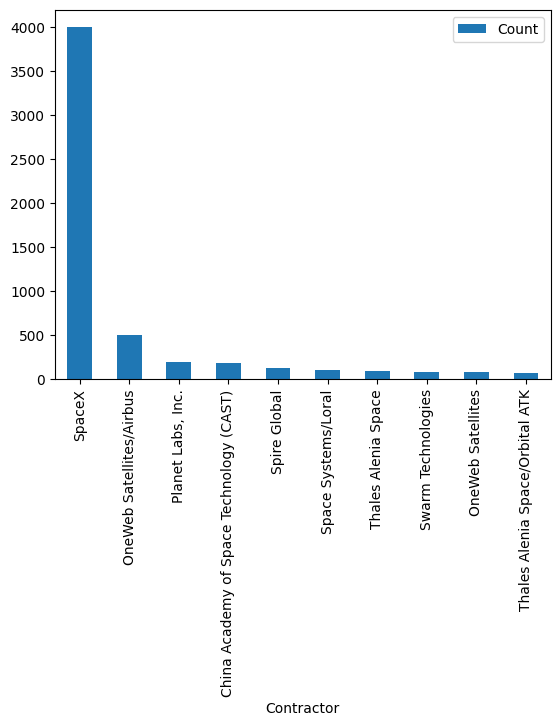

In [31]:
contractor_counts.head(10).plot(kind='bar', x='Contractor')

## Feature Engineering

In [32]:
df['Year of Launch'] = df['Date of Launch'].astype(str).str[-4:]
#df['Year of Launch'] = df['Year of Launch'].astype(int)

In [33]:
df.to_csv('working_dataset.csv')

In [34]:
year_counts = df['Year of Launch'].value_counts().reset_index().sort_values(by='Year of Launch')
year_counts.columns = ['Year of Launch', 'Count']
year_counts.dropna
display(year_counts)

,Year of Launch,Count
34,/018,1
33,1974,1
37,1988,1
35,1989,1
31,1990,2
38,1991,1
36,1992,1
28,1993,3
32,1994,2
27,1995,4


<Axes: xlabel='Year of Launch'>

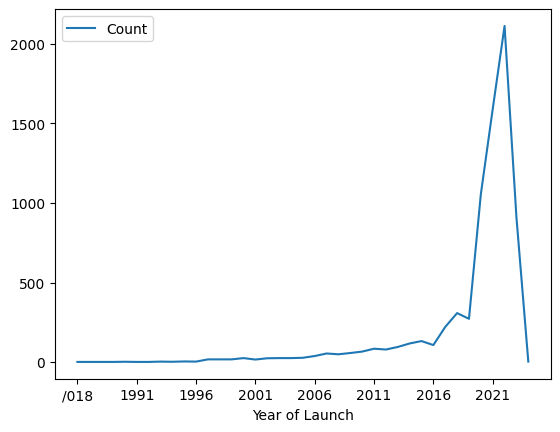

In [35]:
year_counts.plot(kind='line', x='Year of Launch')

## Scraping More Data

https://www.n2yo.com/satellite/?s=65909

API Key:  6UGT66-UVJVBR-RE9FV6-5L9M

Reference:
https://www.n2yo.com/satellite-article/How-many-satellites-can-we-safely-fit-in-Earth-orbit/86

In [36]:
base_url = "https://www.n2yo.com/satellite/?s="
last = 65909 # maybe more - detect failure to find a satellite

In [37]:
from bs4 import BeautifulSoup

def parse_satinfo(html_pages):
    sat_data_list = []

    for html in html_pages:
        soup = BeautifulSoup(html, 'html.parser')
        satinfo_div = soup.find('div', id='satinfo')

        if not satinfo_div:
            continue

        sat_data = {}

        # Extract satellite name
        h1 = satinfo_div.find('h1')
        sat_data['name'] = h1.text.strip() if h1 else None

        # Extract all <b> tags and their following text
        for b_tag in satinfo_div.find_all('b'):
            key = b_tag.text.strip().replace(':', '')
            value = b_tag.next_sibling
            if value:
                sat_data[key] = value.strip()

        sat_data_list.append(sat_data)

    return sat_data_list

html_pages = [html1, html2, html3]  # List of HTML strings
satellite_info = parse_satinfo(html_pages)
print(satellite_info)

NameError: name 'html1' is not defined